In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")

In [4]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
df.shape

(13611, 17)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [7]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [8]:
df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='str')

In [9]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(68)

In [11]:
df[df.duplicated()]

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5548,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5554,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5599,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7263,63408,1005.966,412.551649,196.337705,2.101235,0.879494,64200,284.136539,0.798791,0.987664,0.787385,0.688730,0.006506,0.000903,0.474348,0.996718,HOROZ
7278,63882,1004.206,411.263403,198.765453,2.069089,0.875452,64663,285.196579,0.754705,0.987922,0.796054,0.693465,0.006438,0.000918,0.480893,0.995010,HOROZ
7285,63948,996.497,412.297178,198.877557,2.073121,0.875971,64641,285.343867,0.777909,0.989279,0.809254,0.692083,0.006447,0.000912,0.478979,0.992981,HOROZ
7340,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ


In [12]:
df["Class"].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

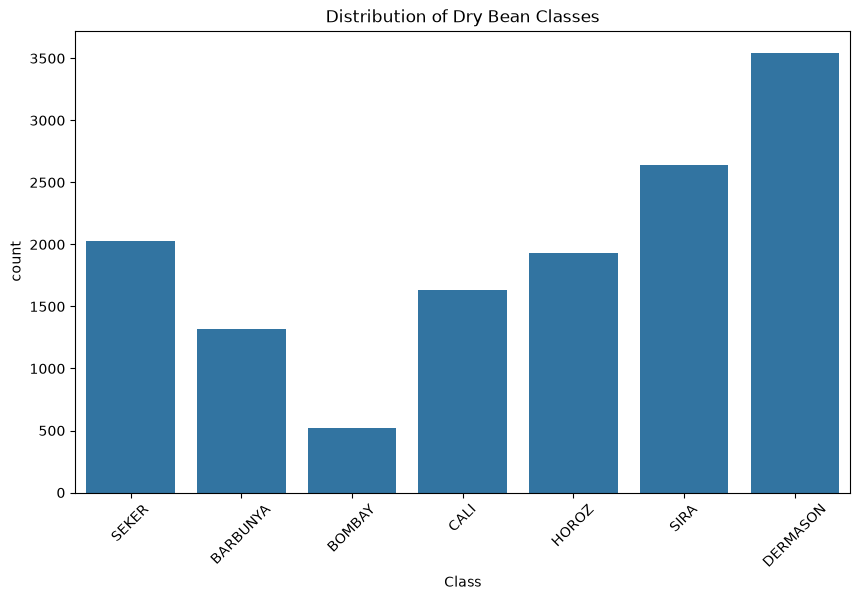

In [13]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribution of Dry Bean Classes")
plt.xticks(rotation=45)
plt.show()

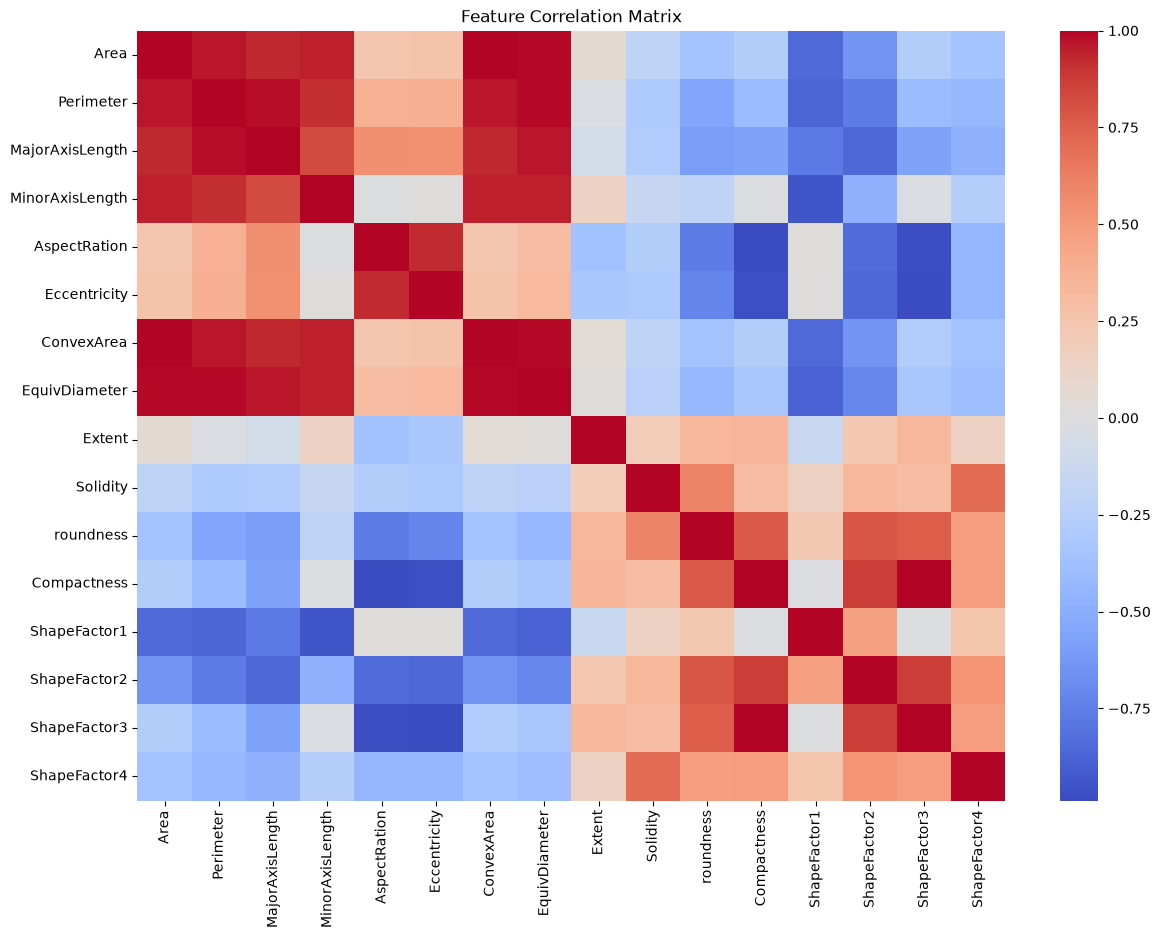

In [14]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.drop(columns=["Class"]).corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

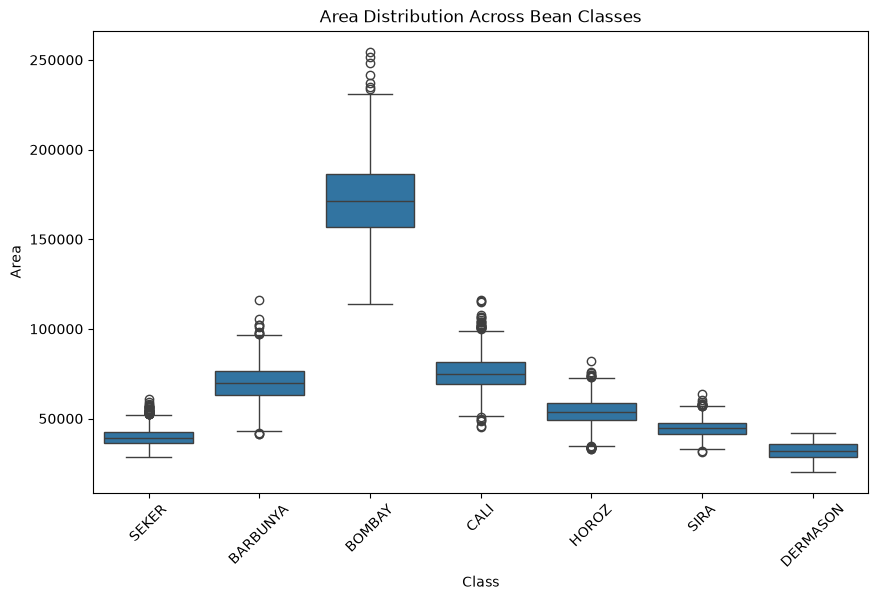

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Area"
)

plt.xticks(rotation=45)
plt.title("Area Distribution Across Bean Classes")
plt.show()

In [16]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [17]:
X.shape

(13611, 16)

In [18]:
y.shape

(13611,)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
from sklearn.neighbors import KNeighborsClassifier

In [23]:
from sklearn.svm import SVC

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [26]:
accuracy_score(y_test, lr_pred)

0.9214102093279471

In [27]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [28]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [29]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.95      0.95      0.95       386
       SEKER       0.95      0.94      0.95       406
        SIRA       0.84      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [30]:
svm = SVC(
    kernel="rbf",
    random_state=42
)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [31]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.94       406
        SIRA       0.86      0.87      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [32]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [33]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.91       709
       HOROZ       0.97      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [34]:
results = []

models = {
    "Logistic Regression": (lr, lr_pred),
    "KNN": (knn, knn_pred),
    "SVM": (svm, svm_pred),
    "Random Forest": (rf, rf_pred)
}

for name, (model, predictions) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted"
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.921410,0.922178,0.921410,0.921590
1,KNN,0.916636,0.917409,0.916636,0.916805
2,SVM,0.922145,0.922426,0.922145,0.922177
3,Random Forest,0.922145,0.922157,0.922145,0.922071


In [35]:
from sklearn.feature_selection import SelectKBest, f_classif

In [36]:
selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_selected = selector.transform(
    X_test_scaled
)

In [37]:
selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'ConvexArea', 'EquivDiameter', 'Compactness',
       'ShapeFactor1', 'ShapeFactor2'],
      dtype='str')


In [38]:
feature_counts = [5, 7, 9, 11, 13, 15, 16]

In [39]:
from sklearn.feature_selection import mutual_info_classif

In [40]:
mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

In [41]:
mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Score": mi_scores
})

mi_df = mi_df.sort_values(
    by="Score",
    ascending=False
)

mi_df

,Feature,Score
1,Perimeter,1.053093
6,ConvexArea,1.038766
7,EquivDiameter,1.031434
0,Area,1.030697
2,MajorAxisLength,0.987720
13,ShapeFactor2,0.948627
12,ShapeFactor1,0.926222
3,MinorAxisLength,0.926209
14,ShapeFactor3,0.831944
11,Compactness,0.831944


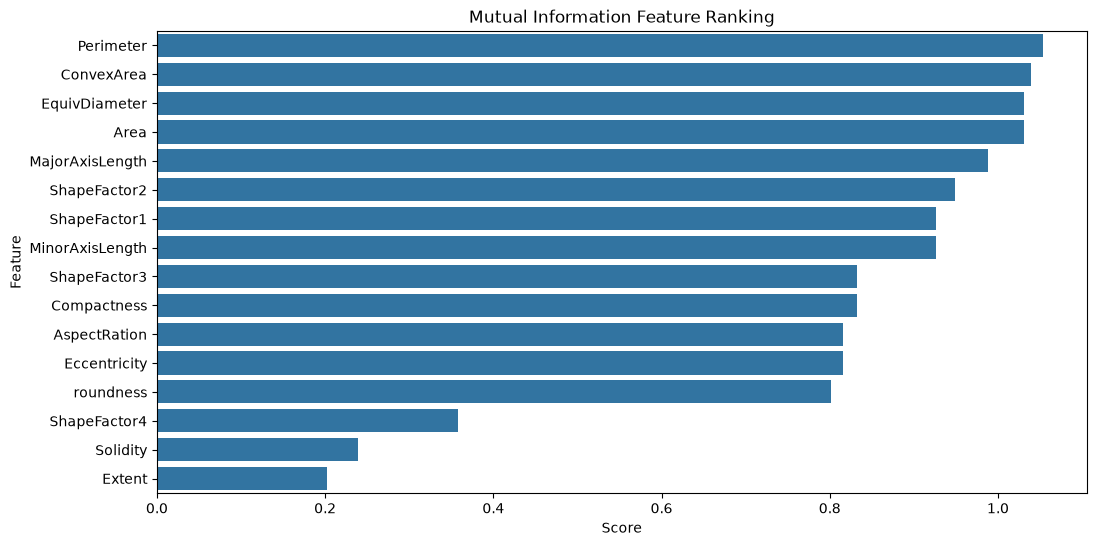

In [42]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=mi_df,
    x="Score",
    y="Feature"
)

plt.title("Mutual Information Feature Ranking")
plt.show()

In [43]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
14,ShapeFactor3,0.108350
1,Perimeter,0.092708
11,Compactness,0.086687
12,ShapeFactor1,0.084266
3,MinorAxisLength,0.080861
2,MajorAxisLength,0.075826
6,ConvexArea,0.070672
0,Area,0.063759
5,Eccentricity,0.062618
7,EquivDiameter,0.058248


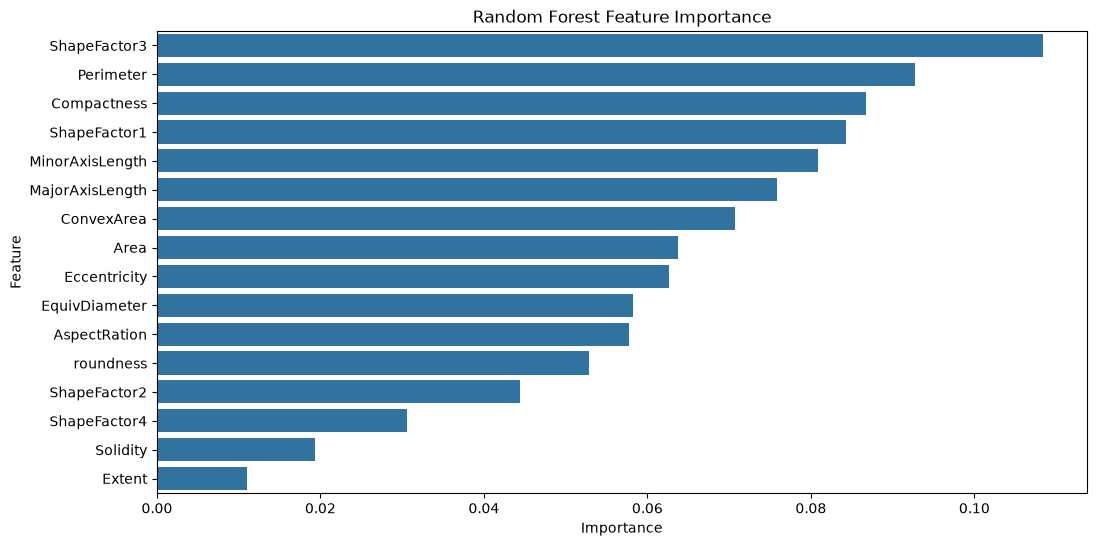

In [44]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

In [45]:
from sklearn.decomposition import PCA

In [46]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

In [47]:
print("Original features:", X_train_scaled.shape[1])
print("PCA components:", X_train_pca.shape[1])

Original features: 16
PCA components: 4


In [48]:
svm_pca = SVC(
    kernel="rbf",
    random_state=42
)

svm_pca.fit(X_train_pca, y_train)

pca_pred = svm_pca.predict(X_test_pca)

In [49]:
print(classification_report(y_test, pca_pred))

              precision    recall  f1-score   support

    BARBUNYA       0.87      0.69      0.77       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.80      0.89      0.85       326
    DERMASON       0.92      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.90      2723
   macro avg       0.91      0.90      0.90      2723
weighted avg       0.90      0.90      0.90      2723



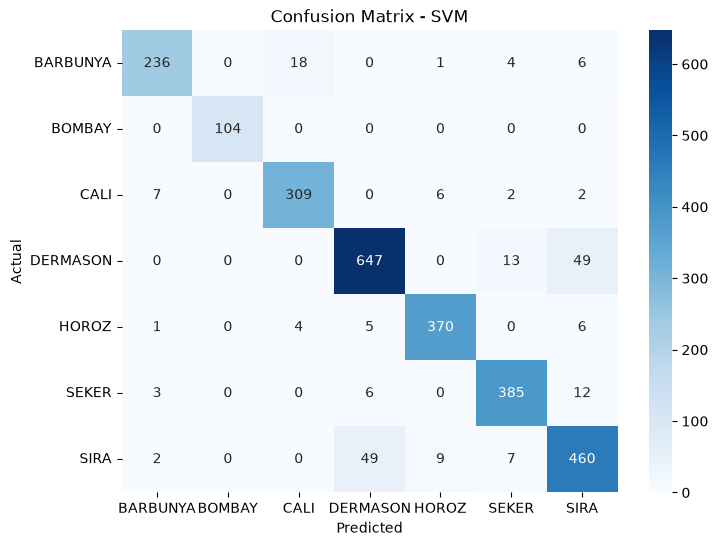

In [54]:
# Confusion Matrix for SVM

cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

In [56]:
# Classification Report for SVM

print("Classification Report - SVM")
print()

print(
    classification_report(
        y_test,
        svm_pred
    )
)

Classification Report - SVM

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.94       406
        SIRA       0.86      0.87      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [57]:
from sklearn.model_selection import cross_val_score

In [58]:
scores = cross_val_score(
    svm,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(scores)
print("Mean:", scores.mean())

[0.93755739 0.92653811 0.92791552 0.92788241 0.93661001]
Mean: 0.9313006880092528


In [59]:
from sklearn.model_selection import GridSearchCV

In [60]:
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "kernel": ["rbf"]
}

In [61]:
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 0.01, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed d

In [62]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
0.9341478002980488


In [63]:
best_model = grid.best_estimator_

In [64]:
final_pred = best_model.predict(X_test_scaled)

In [65]:
accuracy = accuracy_score(
    y_test,
    final_pred
)

precision = precision_score(
    y_test,
    final_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    final_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    final_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9272860815277267
Precision: 0.9272265015191266
Recall   : 0.9272860815277267
F1 Score : 0.9271984201870751


In [66]:
import joblib

joblib.dump(
    best_model,
    "../models/dry_bean_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [67]:
# Display the first row of the dataset

df.iloc[0]

Area                    28395
Perimeter             610.291
MajorAxisLength    208.178117
MinorAxisLength    173.888747
AspectRation         1.197191
Eccentricity         0.549812
ConvexArea              28715
EquivDiameter      190.141097
Extent               0.763923
Solidity             0.988856
roundness            0.958027
Compactness          0.913358
ShapeFactor1         0.007332
ShapeFactor2         0.003147
ShapeFactor3         0.834222
ShapeFactor4         0.998724
Class                   SEKER
Name: 0, dtype: object

In [68]:
# Take the first row's features
sample = df.drop("Class", axis=1).iloc[[0]]

# Actual class
actual_class = df["Class"].iloc[0]

# Scale the sample
sample_scaled = scaler.transform(sample)

# Predict
predicted_class = best_model.predict(sample_scaled)[0]

print("Actual Class    :", actual_class)
print("Predicted Class :", predicted_class)

Actual Class    : SEKER
Predicted Class : SEKER


In [69]:
# Select 20 samples
sample_data = df.drop("Class", axis=1).iloc[:20]

actual_classes = df["Class"].iloc[:20]

# Scale
sample_scaled = scaler.transform(sample_data)

# Predict
predictions = best_model.predict(sample_scaled)

# Compare
comparison = pd.DataFrame({
    "Actual": actual_classes.values,
    "Predicted": predictions
})

comparison

,Actual,Predicted
0,SEKER,SEKER
1,SEKER,SEKER
2,SEKER,SEKER
3,SEKER,SEKER
4,SEKER,SEKER
5,SEKER,SEKER
6,SEKER,SEKER
7,SEKER,SEKER
8,SEKER,SEKER
9,SEKER,SEKER


In [70]:
test_accuracy = accuracy_score(
    actual_classes,
    predictions
)

print("Accuracy on these 20 samples:", test_accuracy)

Accuracy on these 20 samples: 1.0


In [71]:
print(type(best_model))

<class 'sklearn.svm._classes.SVC'>


In [72]:
print(best_model)

SVC(C=10, gamma=0.1)


In [73]:
saved_model = joblib.load("../models/dry_bean_model.pkl")
saved_scaler = joblib.load("../models/scaler.pkl")

print("Saved model:")
print(saved_model)

print("\nSaved scaler:")
print(saved_scaler)

Saved model:
SVC(C=10, gamma=0.1)

Saved scaler:
StandardScaler()


In [74]:
print("Notebook model:")
print(best_model)

Notebook model:
SVC(C=10, gamma=0.1)


In [75]:
print(type(best_model))

<class 'sklearn.svm._classes.SVC'>


In [76]:
print(best_model)

SVC(C=10, gamma=0.1)


In [77]:
sample = df.drop("Class", axis=1).iloc[[0]]

actual_class = df["Class"].iloc[0]

sample_scaled = scaler.transform(sample)

predicted_class = best_model.predict(sample_scaled)[0]

print("Actual Class    :", actual_class)
print("Predicted Class :", predicted_class)

Actual Class    : SEKER
Predicted Class : SEKER


In [78]:
import joblib

# Load the model and scaler saved on disk
saved_model = joblib.load("../models/dry_bean_model.pkl")
saved_scaler = joblib.load("../models/scaler.pkl")

print("Saved Model:")
print(saved_model)

print("\nNotebook Model:")
print(best_model)

print("\nSaved Scaler:")
print(saved_scaler)

Saved Model:
SVC(C=10, gamma=0.1)

Notebook Model:
SVC(C=10, gamma=0.1)

Saved Scaler:
StandardScaler()


In [79]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13611, 16)
y shape: (13611,)


In [80]:
from sklearn.model_selection import train_test_split

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train_fs.shape)
print("Testing shape:", X_test_fs.shape)

Training shape: (10888, 16)
Testing shape: (2723, 16)


In [81]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Scale the data
baseline_scaler = StandardScaler()

X_train_baseline = baseline_scaler.fit_transform(X_train_fs)
X_test_baseline = baseline_scaler.transform(X_test_fs)

# Create the SVM model
baseline_model = SVC(
    C=10,
    gamma=0.1
)

# Measure training time
start_time = time.time()

baseline_model.fit(
    X_train_baseline,
    y_train_fs
)

baseline_training_time = time.time() - start_time

# Predictions
baseline_pred = baseline_model.predict(X_test_baseline)

# Metrics
baseline_accuracy = accuracy_score(y_test_fs, baseline_pred)

baseline_precision = precision_score(
    y_test_fs,
    baseline_pred,
    average="weighted"
)

baseline_recall = recall_score(
    y_test_fs,
    baseline_pred,
    average="weighted"
)

baseline_f1 = f1_score(
    y_test_fs,
    baseline_pred,
    average="weighted"
)

print("Baseline Results - All Features")
print("Number of Features:", X_train_fs.shape[1])
print("Accuracy:", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall:", round(baseline_recall, 4))
print("F1 Score:", round(baseline_f1, 4))
print("Training Time:", round(baseline_training_time, 4), "seconds")

Baseline Results - All Features
Number of Features: 16
Accuracy: 0.9273
Precision: 0.9272
Recall: 0.9273
F1 Score: 0.9272
Training Time: 0.444 seconds


In [82]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 10 features using ANOVA
anova_selector = SelectKBest(
    score_func=f_classif,
    k=10
)

# Fit only on training data
X_train_anova = anova_selector.fit_transform(
    X_train_fs,
    y_train_fs
)

# Transform test data
X_test_anova = anova_selector.transform(
    X_test_fs
)

# Get selected feature names
anova_features = X.columns[
    anova_selector.get_support()
]

print("Selected ANOVA Features:")
print(list(anova_features))

Selected ANOVA Features:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'ConvexArea', 'EquivDiameter', 'Compactness', 'ShapeFactor1', 'ShapeFactor2']


In [83]:
anova_scaler = StandardScaler()

X_train_anova_scaled = anova_scaler.fit_transform(
    X_train_anova
)

X_test_anova_scaled = anova_scaler.transform(
    X_test_anova
)

In [84]:
anova_model = SVC(
    C=10,
    gamma=0.1
)

start_time = time.time()

anova_model.fit(
    X_train_anova_scaled,
    y_train_fs
)

anova_training_time = time.time() - start_time

anova_pred = anova_model.predict(
    X_test_anova_scaled
)

In [85]:
anova_accuracy = accuracy_score(
    y_test_fs,
    anova_pred
)

anova_precision = precision_score(
    y_test_fs,
    anova_pred,
    average="weighted"
)

anova_recall = recall_score(
    y_test_fs,
    anova_pred,
    average="weighted"
)

anova_f1 = f1_score(
    y_test_fs,
    anova_pred,
    average="weighted"
)

print("ANOVA Feature Selection Results")
print("Number of Features:", len(anova_features))
print("Accuracy:", round(anova_accuracy, 4))
print("Precision:", round(anova_precision, 4))
print("Recall:", round(anova_recall, 4))
print("F1 Score:", round(anova_f1, 4))
print("Training Time:", round(anova_training_time, 4), "seconds")

ANOVA Feature Selection Results
Number of Features: 10
Accuracy: 0.9075
Precision: 0.9085
Recall: 0.9075
F1 Score: 0.9076
Training Time: 0.4074 seconds


In [86]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Select top 10 features using Mutual Information
mi_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

# Fit only on training data
X_train_mi = mi_selector.fit_transform(
    X_train_fs,
    y_train_fs
)

# Transform test data
X_test_mi = mi_selector.transform(
    X_test_fs
)

# Get selected feature names
mi_features = X.columns[
    mi_selector.get_support()
]

print("Selected Mutual Information Features:")
print(list(mi_features))

Selected Mutual Information Features:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3']


In [87]:
mi_scaler = StandardScaler()

X_train_mi_scaled = mi_scaler.fit_transform(
    X_train_mi
)

X_test_mi_scaled = mi_scaler.transform(
    X_test_mi
)

In [88]:
mi_model = SVC(
    C=10,
    gamma=0.1
)

start_time = time.time()

mi_model.fit(
    X_train_mi_scaled,
    y_train_fs
)

mi_training_time = time.time() - start_time

mi_pred = mi_model.predict(
    X_test_mi_scaled
)

In [89]:
mi_accuracy = accuracy_score(
    y_test_fs,
    mi_pred
)

mi_precision = precision_score(
    y_test_fs,
    mi_pred,
    average="weighted"
)

mi_recall = recall_score(
    y_test_fs,
    mi_pred,
    average="weighted"
)

mi_f1 = f1_score(
    y_test_fs,
    mi_pred,
    average="weighted"
)

print("Mutual Information Results")
print("Number of Features:", len(mi_features))
print("Accuracy:", round(mi_accuracy, 4))
print("Precision:", round(mi_precision, 4))
print("Recall:", round(mi_recall, 4))
print("F1 Score:", round(mi_f1, 4))
print("Training Time:", round(mi_training_time, 4), "seconds")

Mutual Information Results
Number of Features: 10
Accuracy: 0.9064
Precision: 0.9074
Recall: 0.9064
F1 Score: 0.9064
Training Time: 0.4029 seconds


In [90]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest for feature importance
rf_selector_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_selector_model.fit(
    X_train_fs,
    y_train_fs
)

# Get feature importance
rf_importance = pd.Series(
    rf_selector_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Random Forest Feature Importance:")
print(rf_importance)

Random Forest Feature Importance:
ShapeFactor3       0.108350
Perimeter          0.092708
Compactness        0.086687
ShapeFactor1       0.084266
MinorAxisLength    0.080861
MajorAxisLength    0.075826
ConvexArea         0.070672
Area               0.063759
Eccentricity       0.062618
EquivDiameter      0.058248
AspectRation       0.057794
roundness          0.052820
ShapeFactor2       0.044430
ShapeFactor4       0.030544
Solidity           0.019362
Extent             0.011055
dtype: float64


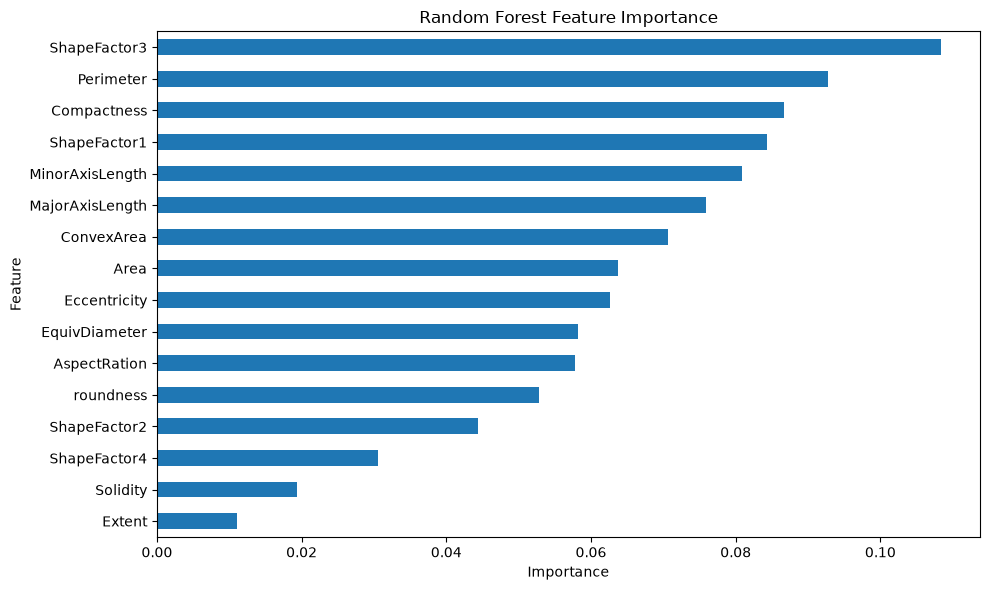

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

rf_importance.sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [92]:
# Select top 10 features
rf_features = rf_importance.head(10).index

print("Top 10 Random Forest Features:")
print(list(rf_features))

Top 10 Random Forest Features:
['ShapeFactor3', 'Perimeter', 'Compactness', 'ShapeFactor1', 'MinorAxisLength', 'MajorAxisLength', 'ConvexArea', 'Area', 'Eccentricity', 'EquivDiameter']


In [93]:
X_train_rf = X_train_fs[rf_features]
X_test_rf = X_test_fs[rf_features]

print("Training shape:", X_train_rf.shape)
print("Testing shape:", X_test_rf.shape)

Training shape: (10888, 10)
Testing shape: (2723, 10)


In [94]:
rf_scaler = StandardScaler()

X_train_rf_scaled = rf_scaler.fit_transform(
    X_train_rf
)

X_test_rf_scaled = rf_scaler.transform(
    X_test_rf
)

In [95]:
rf_svm_model = SVC(
    C=10,
    gamma=0.1
)

start_time = time.time()

rf_svm_model.fit(
    X_train_rf_scaled,
    y_train_fs
)

rf_training_time = time.time() - start_time

rf_pred = rf_svm_model.predict(
    X_test_rf_scaled
)

In [96]:
rf_accuracy = accuracy_score(
    y_test_fs,
    rf_pred
)

rf_precision = precision_score(
    y_test_fs,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test_fs,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test_fs,
    rf_pred,
    average="weighted"
)

print("Random Forest Feature Selection Results")
print("Number of Features:", len(rf_features))
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1 Score:", round(rf_f1, 4))
print("Training Time:", round(rf_training_time, 4), "seconds")

Random Forest Feature Selection Results
Number of Features: 10
Accuracy: 0.9078
Precision: 0.909
Recall: 0.9078
F1 Score: 0.908
Training Time: 0.3699 seconds


In [97]:
from sklearn.decomposition import PCA

In [98]:
pca_scaler = StandardScaler()

X_train_pca_scaled = pca_scaler.fit_transform(
    X_train_fs
)

X_test_pca_scaled = pca_scaler.transform(
    X_test_fs
)

print("Original number of features:", X_train_fs.shape[1])

Original number of features: 16


In [99]:
pca = PCA(
    n_components=10,
    random_state=42
)

X_train_pca = pca.fit_transform(
    X_train_pca_scaled
)

X_test_pca = pca.transform(
    X_test_pca_scaled
)

print("Original features:", X_train_fs.shape[1])
print("PCA components:", X_train_pca.shape[1])

Original features: 16
PCA components: 10


In [100]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance by each component:")

for i, variance in enumerate(explained_variance, start=1):
    print(
        f"PC{i}: {variance:.4f} "
        f"({variance * 100:.2f}%)"
    )

print(
    "\nTotal explained variance:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Explained variance by each component:
PC1: 0.5545 (55.45%)
PC2: 0.2646 (26.46%)
PC3: 0.0804 (8.04%)
PC4: 0.0510 (5.10%)
PC5: 0.0271 (2.71%)
PC6: 0.0114 (1.14%)
PC7: 0.0070 (0.70%)
PC8: 0.0032 (0.32%)
PC9: 0.0005 (0.05%)
PC10: 0.0001 (0.01%)

Total explained variance: 99.99 %


In [101]:
pca_model = SVC(
    C=10,
    gamma=0.1
)

start_time = time.time()

pca_model.fit(
    X_train_pca,
    y_train_fs
)

pca_training_time = time.time() - start_time

pca_pred = pca_model.predict(
    X_test_pca
)

In [102]:
pca_accuracy = accuracy_score(
    y_test_fs,
    pca_pred
)

pca_precision = precision_score(
    y_test_fs,
    pca_pred,
    average="weighted"
)

pca_recall = recall_score(
    y_test_fs,
    pca_pred,
    average="weighted"
)

pca_f1 = f1_score(
    y_test_fs,
    pca_pred,
    average="weighted"
)

print("PCA Results")
print("Number of Components:", X_train_pca.shape[1])
print("Accuracy:", round(pca_accuracy, 4))
print("Precision:", round(pca_precision, 4))
print("Recall:", round(pca_recall, 4))
print("F1 Score:", round(pca_f1, 4))
print("Training Time:", round(pca_training_time, 4), "seconds")

PCA Results
Number of Components: 10
Accuracy: 0.9273
Precision: 0.9272
Recall: 0.9273
F1 Score: 0.9272
Training Time: 0.5045 seconds


In [103]:
print(
    "Total explained variance:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

Total explained variance: 99.99 %


In [104]:
for i, variance in enumerate(
    pca.explained_variance_ratio_,
    start=1
):
    print(
        f"PC{i}: {variance * 100:.2f}%"
    )

PC1: 55.45%
PC2: 26.46%
PC3: 8.04%
PC4: 5.10%
PC5: 2.71%
PC6: 1.14%
PC7: 0.70%
PC8: 0.32%
PC9: 0.05%
PC10: 0.01%


In [105]:
results = pd.DataFrame({
    "Method": [
        "All Features",
        "ANOVA",
        "Mutual Information",
        "Random Forest",
        "PCA"
    ],

    "Features": [
        16,
        10,
        10,
        10,
        10
    ],

    "Accuracy": [
        baseline_accuracy,
        anova_accuracy,
        mi_accuracy,
        rf_accuracy,
        pca_accuracy
    ],

    "Precision": [
        baseline_precision,
        anova_precision,
        mi_precision,
        rf_precision,
        pca_precision
    ],

    "Recall": [
        baseline_recall,
        anova_recall,
        mi_recall,
        rf_recall,
        pca_recall
    ],

    "F1 Score": [
        baseline_f1,
        anova_f1,
        mi_f1,
        rf_f1,
        pca_f1
    ],

    "Training Time (seconds)": [
        baseline_training_time,
        anova_training_time,
        mi_training_time,
        rf_training_time,
        pca_training_time
    ]
})

results

,Method,Features,Accuracy,Precision,Recall,F1 Score,Training Time (seconds)
0,All Features,16,0.927286,0.927227,0.927286,0.927198,0.443997
1,ANOVA,10,0.907455,0.908513,0.907455,0.907628,0.407422
2,Mutual Information,10,0.906353,0.907351,0.906353,0.906441,0.402941
3,Random Forest,10,0.907822,0.908951,0.907822,0.908035,0.369856
4,PCA,10,0.927286,0.927227,0.927286,0.927198,0.504470


In [106]:
results_display = results.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:
    results_display[column] = (
        results_display[column] * 100
    ).round(2)

results_display

,Method,Features,Accuracy,Precision,Recall,F1 Score,Training Time (seconds)
0,All Features,16,92.73,92.72,92.73,92.72,0.443997
1,ANOVA,10,90.75,90.85,90.75,90.76,0.407422
2,Mutual Information,10,90.64,90.74,90.64,90.64,0.402941
3,Random Forest,10,90.78,90.90,90.78,90.80,0.369856
4,PCA,10,92.73,92.72,92.73,92.72,0.504470


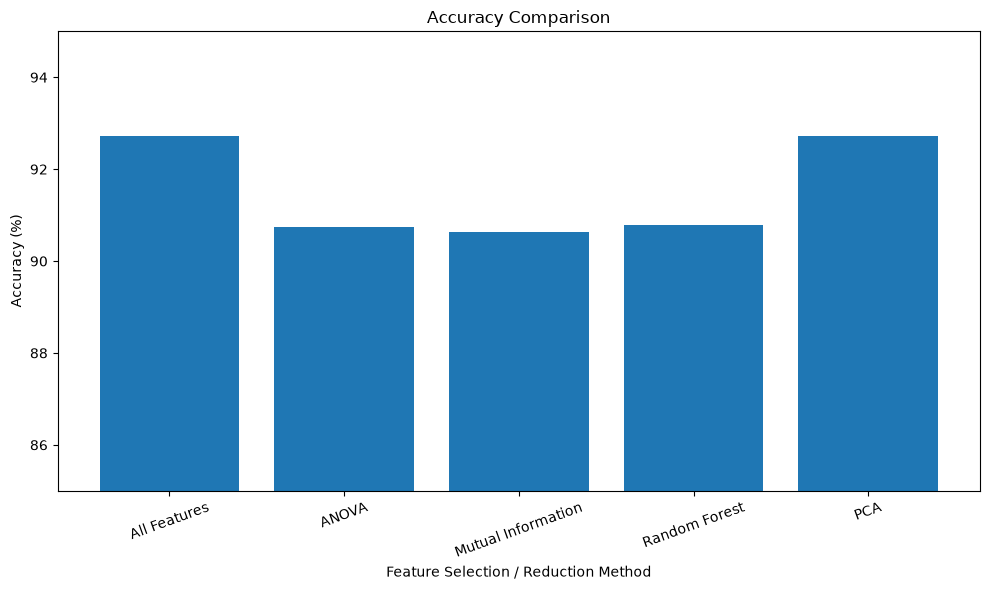

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    results_display["Method"],
    results_display["Accuracy"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Feature Selection / Reduction Method")
plt.title("Accuracy Comparison")

plt.ylim(85, 95)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

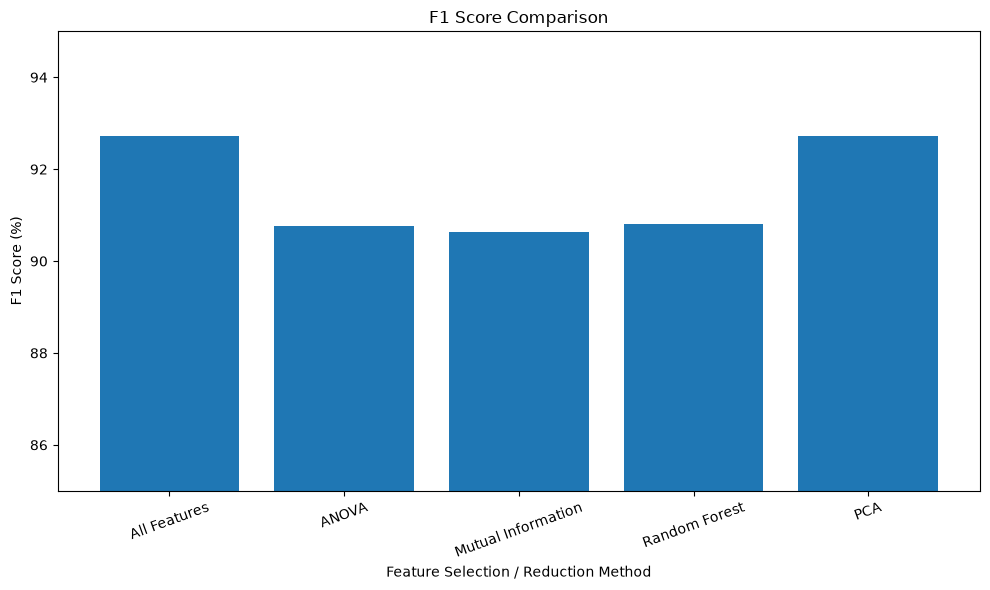

In [108]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_display["Method"],
    results_display["F1 Score"]
)

plt.ylabel("F1 Score (%)")
plt.xlabel("Feature Selection / Reduction Method")
plt.title("F1 Score Comparison")

plt.ylim(85, 95)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

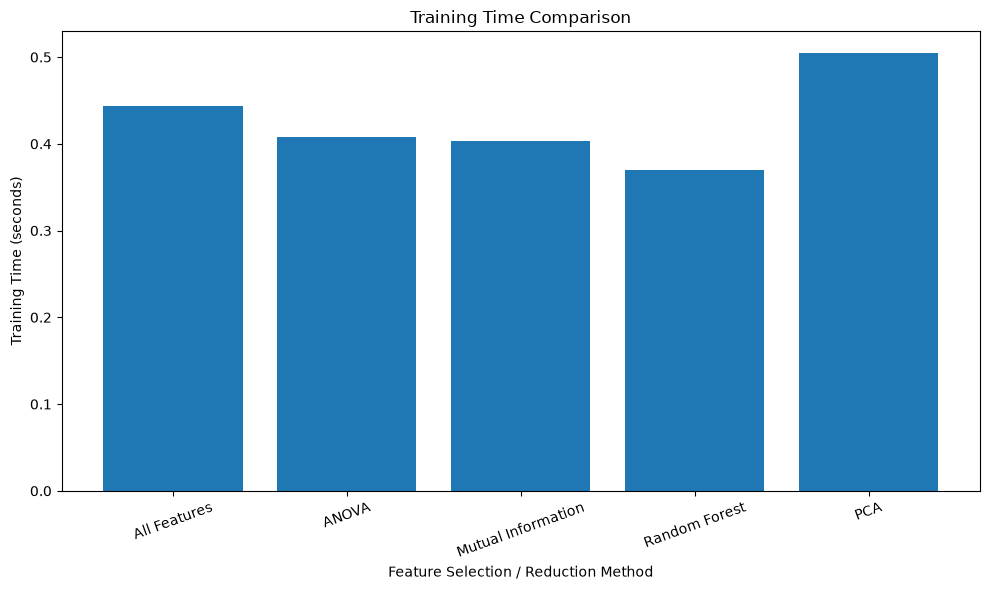

In [109]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Method"],
    results["Training Time (seconds)"]
)

plt.ylabel("Training Time (seconds)")
plt.xlabel("Feature Selection / Reduction Method")
plt.title("Training Time Comparison")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [110]:
from sklearn.metrics import classification_report

# Generate classification report
print("Classification Report - All Features SVM")
print(
    classification_report(
        y_test_fs,
        baseline_pred
    )
)

Classification Report - All Features SVM
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.93      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.88      0.87      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



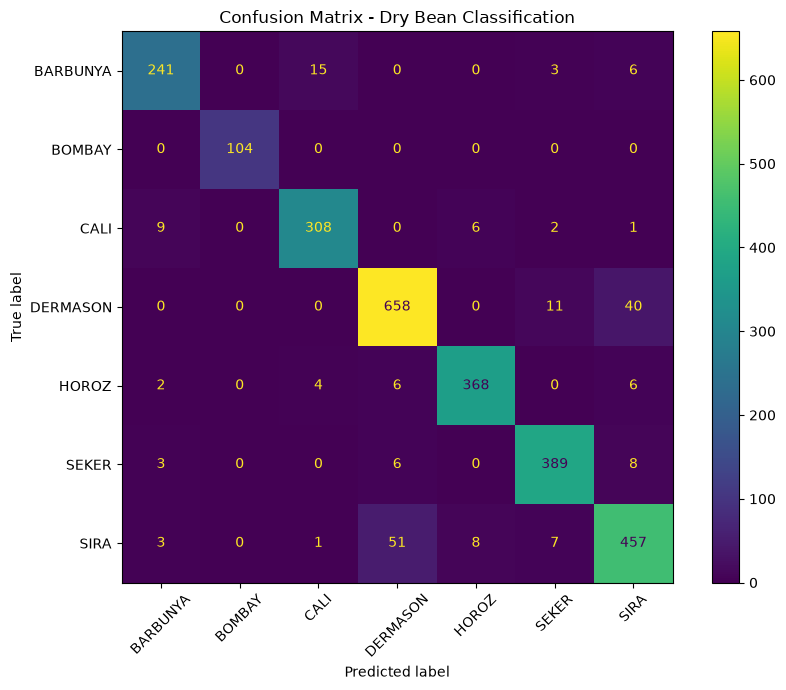

In [111]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(
    y_test_fs,
    baseline_pred
)

# Get class names
class_names = sorted(y_test_fs.unique())

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Dry Bean Classification")
plt.tight_layout()
plt.show()

In [112]:
import numpy as np

# Copy confusion matrix
cm_without_diagonal = cm.copy()

# Remove diagonal values
np.fill_diagonal(
    cm_without_diagonal,
    0
)

# Find largest confusion
max_index = np.unravel_index(
    np.argmax(cm_without_diagonal),
    cm_without_diagonal.shape
)

actual_class = class_names[max_index[0]]
predicted_class = class_names[max_index[1]]

print(
    "Most confused classes:"
)

print(
    f"Actual: {actual_class}"
)

print(
    f"Predicted: {predicted_class}"
)

print(
    "Number of misclassifications:",
    cm_without_diagonal[max_index]
)

Most confused classes:
Actual: SIRA
Predicted: DERMASON
Number of misclassifications: 51


In [113]:
class_accuracy = {}

for i, class_name in enumerate(class_names):

    correct = cm[i, i]
    total = cm[i].sum()

    accuracy = correct / total

    class_accuracy[class_name] = accuracy

for class_name, accuracy in class_accuracy.items():

    print(
        f"{class_name}: "
        f"{accuracy * 100:.2f}%"
    )

BARBUNYA: 90.94%
BOMBAY: 100.00%
CALI: 94.48%
DERMASON: 92.81%
HOROZ: 95.34%
SEKER: 95.81%
SIRA: 86.72%


In [114]:
results_display.to_csv(
    "feature_selection_results.csv",
    index=False
)

print(
    "Results saved successfully!"
)

Results saved successfully!


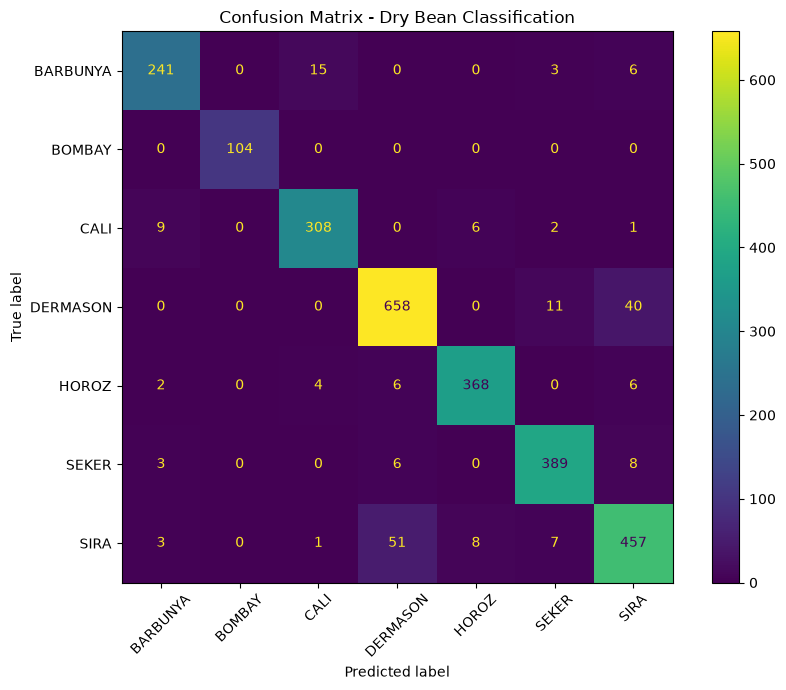

In [115]:
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Dry Bean Classification")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

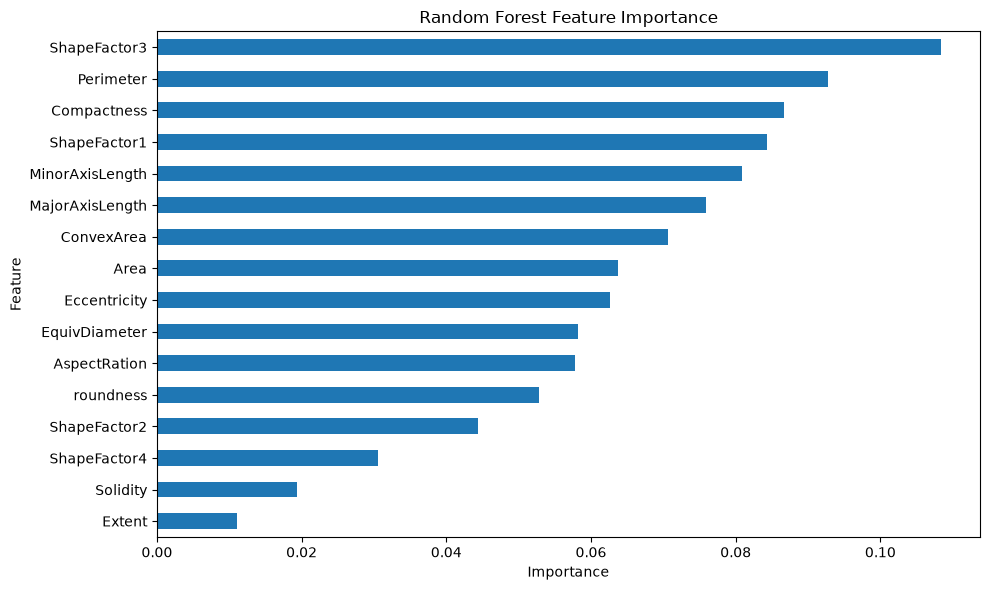

In [116]:
plt.figure(figsize=(10, 6))

rf_importance.sort_values().plot(
    kind="barh"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

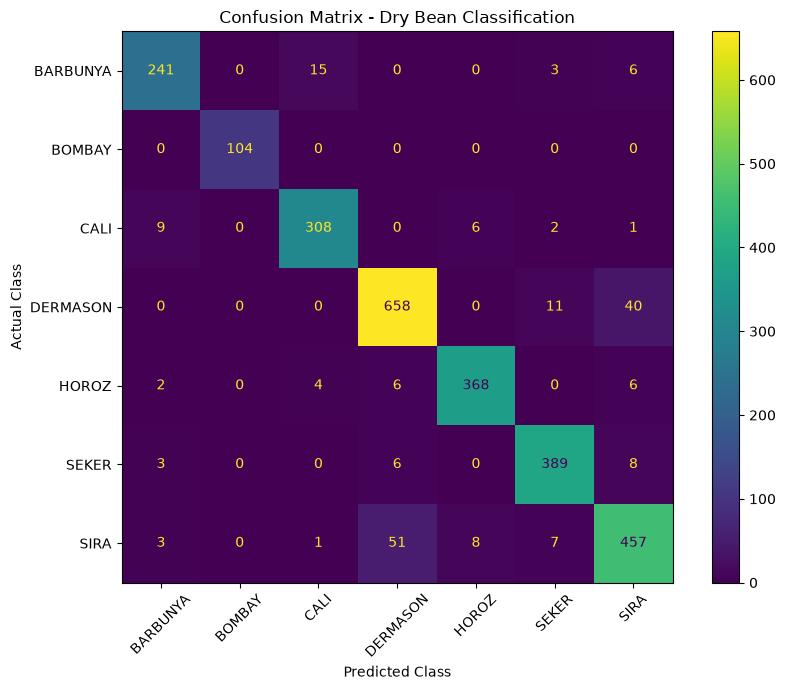

In [117]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(
    y_test_fs,
    baseline_pred
)

# Class names
class_names = sorted(y_test_fs.unique())

# Display confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Dry Bean Classification")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.show()

In [118]:
import numpy as np

# Copy confusion matrix
cm_errors = cm.copy()

# Ignore correct predictions
np.fill_diagonal(cm_errors, 0)

# Find largest error
max_index = np.unravel_index(
    np.argmax(cm_errors),
    cm_errors.shape
)

actual_class = class_names[max_index[0]]
predicted_class = class_names[max_index[1]]
error_count = cm_errors[max_index]

print("Most frequent misclassification:")
print("Actual class   :", actual_class)
print("Predicted class:", predicted_class)
print("Number of cases:", error_count)

Most frequent misclassification:
Actual class   : SIRA
Predicted class: DERMASON
Number of cases: 51


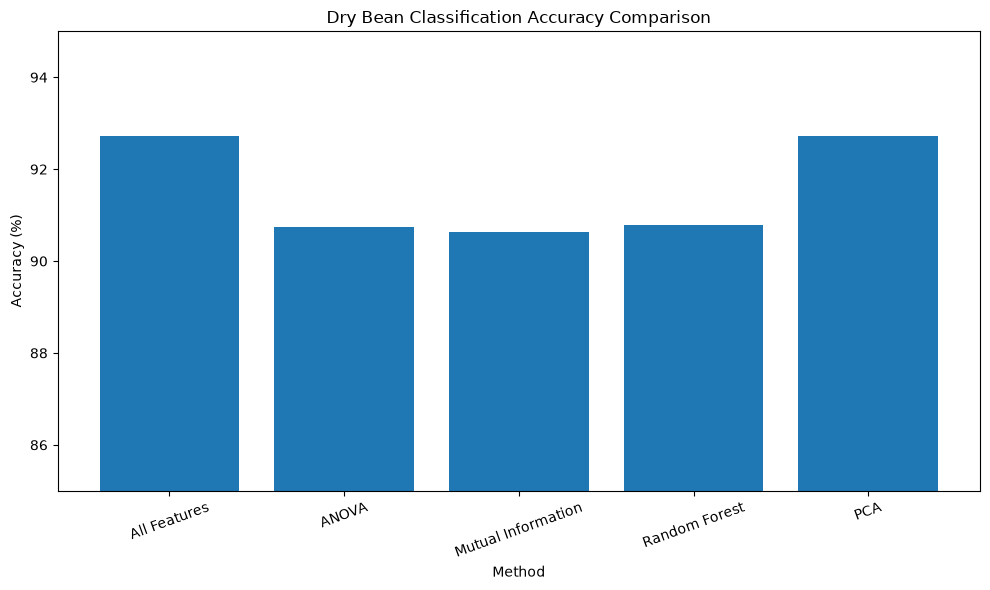

In [119]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_display["Method"],
    results_display["Accuracy"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Method")
plt.title("Dry Bean Classification Accuracy Comparison")

plt.ylim(85, 95)
plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [120]:
final_results = results_display.copy()

final_results

,Method,Features,Accuracy,Precision,Recall,F1 Score,Training Time (seconds)
0,All Features,16,92.73,92.72,92.73,92.72,0.443997
1,ANOVA,10,90.75,90.85,90.75,90.76,0.407422
2,Mutual Information,10,90.64,90.74,90.64,90.64,0.402941
3,Random Forest,10,90.78,90.90,90.78,90.80,0.369856
4,PCA,10,92.73,92.72,92.73,92.72,0.504470


In [121]:
model_summary = {
    "Algorithm": "Support Vector Machine",
    "Kernel": "RBF",
    "C": 10,
    "Gamma": 0.1,
    "Number of Features": 16,
    "Accuracy": 0.9273,
    "Precision": 0.9272,
    "Recall": 0.9273,
    "F1 Score": 0.9272
}

model_summary

{'Algorithm': 'Support Vector Machine',
 'Kernel': 'RBF',
 'C': 10,
 'Gamma': 0.1,
 'Number of Features': 16,
 'Accuracy': 0.9273,
 'Precision': 0.9272,
 'Recall': 0.9273,
 'F1 Score': 0.9272}